# Dimensionality Reduction with PCA — Live Demo

**Goal:** show how Principal Component Analysis (PCA) compresses many features into a few, while keeping as much information (variance) as possible.

| Demo | Original features | Reduced to | Extra step |
|---|---|---|---|
| 1. Iris flowers | 4 | 2 | — |
| 2. Handwritten digits | 64 | 2 | K-Means clustering |

**Key idea:** PCA finds new axes (principal components) that are linear combinations of the original features, ordered by how much variance they capture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)
RANDOM_STATE = 42

---
## Part 1 — Iris: 4 features → 2

150 flowers, 3 species, 4 measurements each (sepal length/width, petal length/width).

In [2]:
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target
species = iris.target_names

print("Shape:", X_iris.shape)
X_iris.head()

Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### Step 1: Standardize
PCA is driven by variance, so features on larger scales would dominate. We scale every feature to mean 0 and standard deviation 1 first.

In [3]:
X_iris_scaled = StandardScaler().fit_transform(X_iris)

### Step 2: Fit PCA with 2 components

In [4]:
pca_iris = PCA(n_components=2, random_state=RANDOM_STATE)
X_iris_pca = pca_iris.fit_transform(X_iris_scaled)

print("Original shape:", X_iris_scaled.shape)
print("Reduced shape: ", X_iris_pca.shape)
print()
print("explained_variance_ratio_:", pca_iris.explained_variance_ratio_)
print("Total variance kept:      ", pca_iris.explained_variance_ratio_.sum().round(4))

Original shape: (150, 4)
Reduced shape:  (150, 2)

explained_variance_ratio_: [0.7296 0.2285]
Total variance kept:       0.9581


**Talking point:** PC1 alone captures roughly 73% of the variance and PC2 about 23%, so two numbers per flower keep ~96% of the information in the original four.

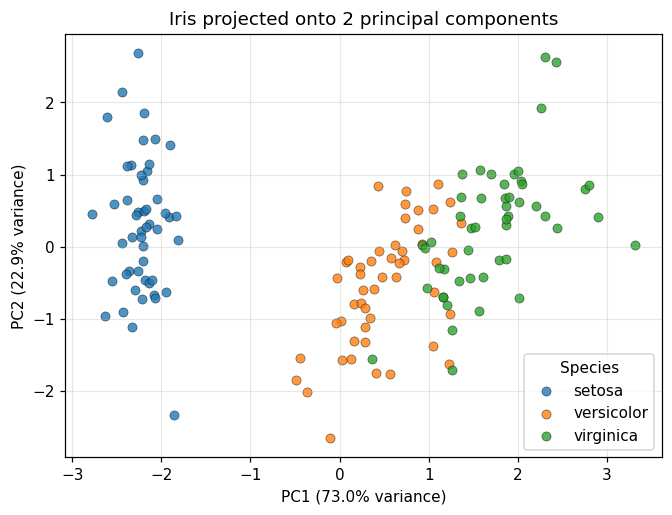

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, name in enumerate(species):
    mask = y_iris == i
    ax.scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1], label=name, alpha=0.8, edgecolor="k", linewidth=0.3)
ax.set_xlabel(f"PC1 ({pca_iris.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca_iris.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Iris projected onto 2 principal components")
ax.legend(title="Species")
ax.grid(alpha=0.3)
plt.show()

### What do the components mean?
The **loadings** show how much each original feature contributes to each PC.

In [6]:
loadings = pd.DataFrame(
    pca_iris.components_.T,
    columns=["PC1", "PC2"],
    index=iris.feature_names,
)
loadings

,PC1,PC2
sepal length (cm),0.521066,0.377418
sepal width (cm),-0.269347,0.923296
petal length (cm),0.580413,0.024492
petal width (cm),0.564857,0.066942


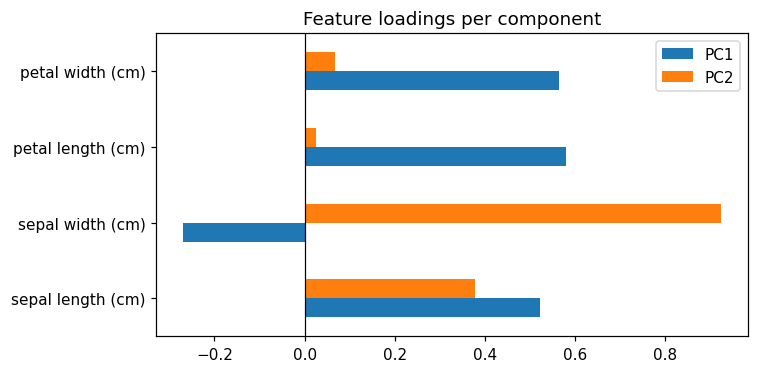

In [7]:
loadings.plot(kind="barh", figsize=(7, 3.5), title="Feature loadings per component")
plt.axvline(0, color="k", lw=0.8)
plt.tight_layout()
plt.show()

**Talking point:** PC1 is mostly a "petal size" axis (petal length/width and sepal length all load together) — it separates *setosa* from the others. 

### How many components do we really need?
Fit with all 4 components and look at the cumulative variance.

explained_variance_ratio_: [0.7296 0.2285 0.0367 0.0052]
cumulative:                [0.7296 0.9581 0.9948 1.    ]


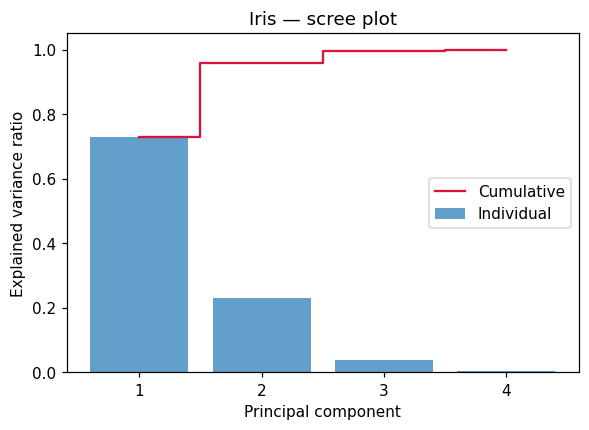

In [8]:
pca_iris_full = PCA(random_state=RANDOM_STATE).fit(X_iris_scaled)
evr = pca_iris_full.explained_variance_ratio_
cum = np.cumsum(evr)

print("explained_variance_ratio_:", evr)
print("cumulative:               ", cum)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(1, 5), evr, alpha=0.7, label="Individual")
ax.step(range(1, 5), cum, where="mid", color="crimson", label="Cumulative")
ax.set_xticks(range(1, 5))
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("Iris — scree plot")
ax.legend()
plt.show()

---
## Part 2 — Handwritten digits: 64 features → 2, then K-Means

1,797 images of handwritten digits (0–9). Each is an 8×8 grayscale image = **64 pixel features**.

Shape: (1797, 64) (samples, pixel features)


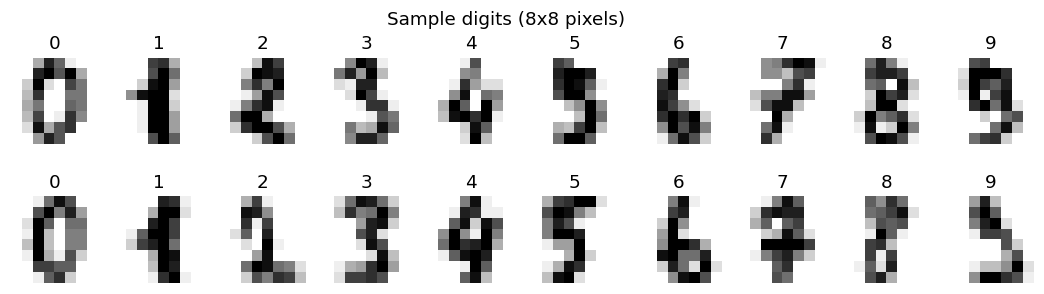

In [9]:
digits = load_digits()
X_dig = digits.data
y_dig = digits.target

print("Shape:", X_dig.shape, "(samples, pixel features)")

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for ax, img, lbl in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap="gray_r")
    ax.set_title(lbl)
    ax.axis("off")
plt.suptitle("Sample digits (8x8 pixels)")
plt.show()

In [10]:
X_dig_scaled = StandardScaler().fit_transform(X_dig)

pca_dig = PCA(n_components=2, random_state=RANDOM_STATE)
X_dig_pca = pca_dig.fit_transform(X_dig_scaled)

print("Original shape:", X_dig_scaled.shape)
print("Reduced shape: ", X_dig_pca.shape)
print()
print("explained_variance_ratio_:", pca_dig.explained_variance_ratio_)
print("Total variance kept:      ", pca_dig.explained_variance_ratio_.sum().round(4))

Original shape: (1797, 64)
Reduced shape:  (1797, 2)

explained_variance_ratio_: [0.1203 0.0956]
Total variance kept:       0.2159


**Talking point:** Unlike Iris, 2 components keep only ~22% of the variance here. We are throwing away a lot — but let's see whether the structure survives anyway.

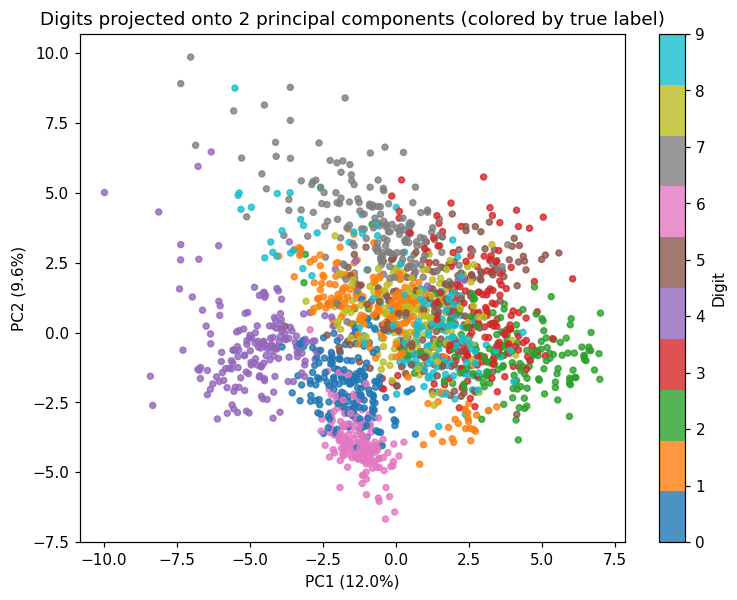

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_dig_pca[:, 0], X_dig_pca[:, 1], c=y_dig, cmap="tab10", s=15, alpha=0.8)
ax.set_xlabel(f"PC1 ({pca_dig.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_dig.explained_variance_ratio_[1]:.1%})")
ax.set_title("Digits projected onto 2 principal components (colored by true label)")
cbar = plt.colorbar(sc, ax=ax, ticks=range(10))
cbar.set_label("Digit")
plt.show()

### K-Means on the 2-D PCA result
We pretend we **don't know the labels**, ask K-Means for 10 clusters, then compare to the true digits.

In [12]:
kmeans = KMeans(n_clusters=10, n_init=10, random_state=RANDOM_STATE)
clusters = kmeans.fit_predict(X_dig_pca)

print("Adjusted Rand Index vs true labels:", round(adjusted_rand_score(y_dig, clusters), 3))
print("Silhouette score:                  ", round(silhouette_score(X_dig_pca, clusters), 3))

Adjusted Rand Index vs true labels: 0.326
Silhouette score:                   0.378


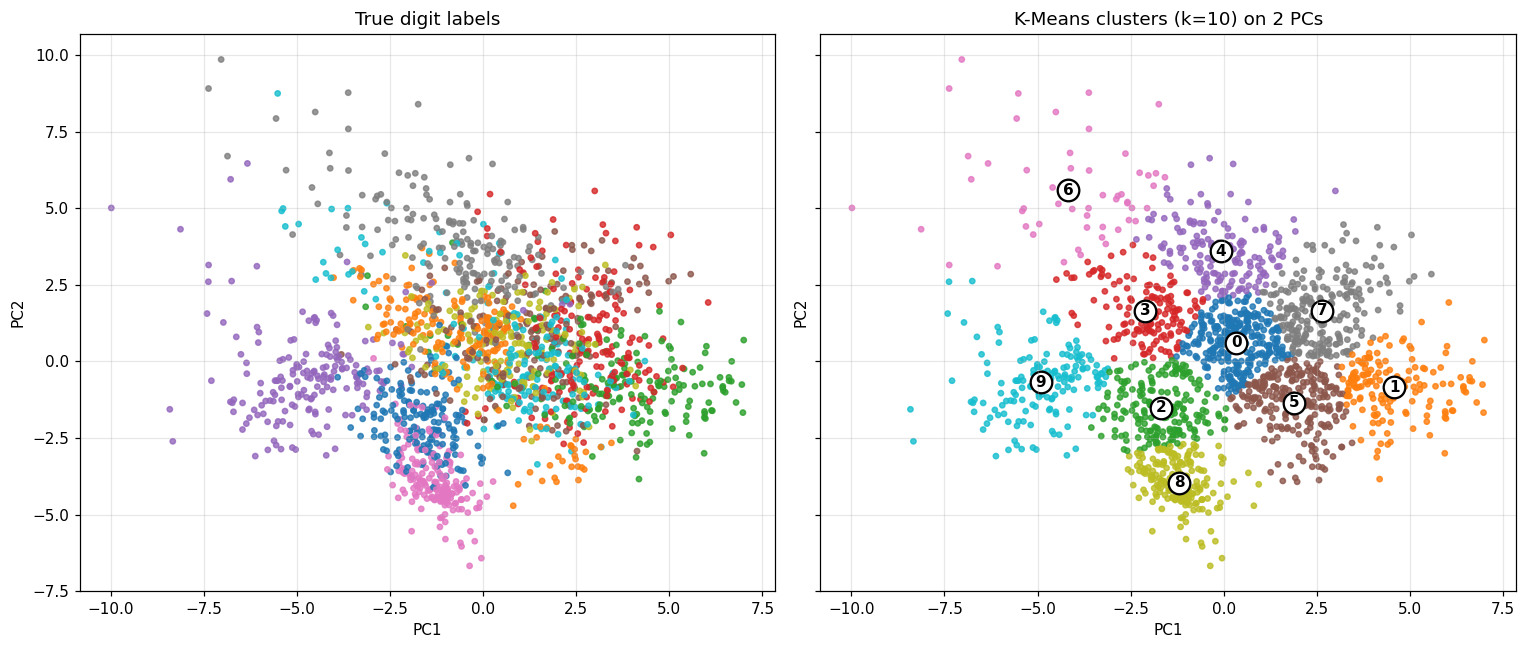

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].scatter(X_dig_pca[:, 0], X_dig_pca[:, 1], c=y_dig, cmap="tab10", s=12, alpha=0.8)
axes[0].set_title("True digit labels")

axes[1].scatter(X_dig_pca[:, 0], X_dig_pca[:, 1], c=clusters, cmap="tab10", s=12, alpha=0.8)
centers = kmeans.cluster_centers_
axes[1].scatter(centers[:, 0], centers[:, 1], c="white", edgecolor="k", s=200, marker="o", linewidth=1.5)
for i, (cx, cy) in enumerate(centers):
    axes[1].text(cx, cy, str(i), ha="center", va="center", fontweight="bold")
axes[1].set_title("K-Means clusters (k=10) on 2 PCs")

for ax in axes:
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Talking point:** Several digits (e.g., 0, 4, 6) form fairly distinct groups, while others (like 3, 5, 8, 9) overlap heavily. That overlap is the price of squeezing 64 dimensions into 2.

### Which true digit does each cluster mostly contain?

In [14]:
ct = pd.crosstab(pd.Series(clusters, name="K-Means cluster"), pd.Series(y_dig, name="True digit"))
ct.style.background_gradient(cmap="Blues", axis=None)

True digit,0,1,2,3,4,5,6,7,8,9
K-Means cluster,,,,,,,,,,
0,3,75,9,7,1,55,0,11,74,49
1,0,0,107,39,0,3,0,0,2,7
2,126,7,1,4,13,10,20,0,9,3
3,2,67,5,0,12,9,1,14,22,9
4,0,4,1,15,0,11,0,107,8,11
5,2,27,35,42,0,27,0,0,30,68
6,0,0,0,0,6,0,0,35,0,12
7,0,0,19,76,2,66,0,12,29,21
8,40,2,0,0,0,0,160,0,0,0


### Does more components help?
How many components to keep ~90% of the variance in the digits data? And does clustering improve?

First 10 explained_variance_ratio_: [0.1203 0.0956 0.0844 0.065  0.0486 0.0421 0.0394 0.0339 0.03   0.0293]

Components needed for 90% variance: 31 (out of 64)


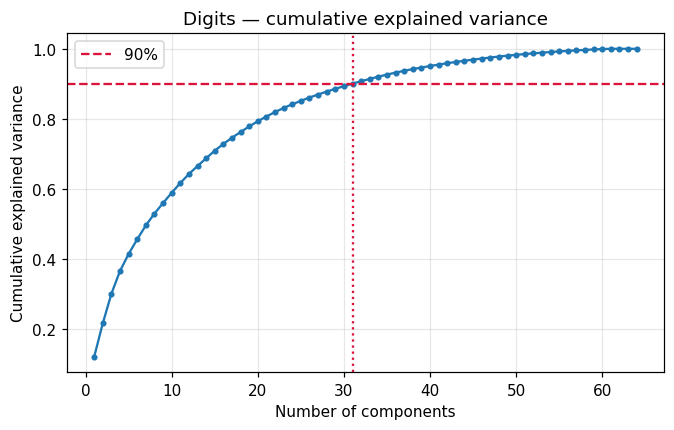

In [15]:
pca_dig_full = PCA(random_state=RANDOM_STATE).fit(X_dig_scaled)
evr_d = pca_dig_full.explained_variance_ratio_
cum_d = np.cumsum(evr_d)

print("First 10 explained_variance_ratio_:", evr_d[:10])
n90 = int(np.argmax(cum_d >= 0.90) + 1)
print(f"\nComponents needed for 90% variance: {n90} (out of 64)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 65), cum_d, marker="o", ms=3)
ax.axhline(0.90, color="crimson", ls="--", label="90%")
ax.axvline(n90, color="crimson", ls=":")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Digits — cumulative explained variance")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [16]:
rows = []
for n in [2, 5, 10, n90, 64]:
    Xp = PCA(n_components=n, random_state=RANDOM_STATE).fit_transform(X_dig_scaled)
    lab = KMeans(n_clusters=10, n_init=10, random_state=RANDOM_STATE).fit_predict(Xp)
    rows.append({"n_components": n,
                 "variance_kept": cum_d[n-1],
                 "adjusted_rand_index": adjusted_rand_score(y_dig, lab)})
pd.DataFrame(rows).round(3)

,n_components,variance_kept,adjusted_rand_index
0,2,0.216,0.326
1,5,0.414,0.422
2,10,0.589,0.483
3,31,0.900,0.463
4,64,1.000,0.534


**Talking point:** Clustering quality improves substantially with 10–20 components, so 2-D is great for *visualization*, but not necessarily the best input for *downstream modelling*.

---
## Takeaways

1. **Scale first** — PCA is sensitive to feature scale.
2. **`explained_variance_ratio_`** tells you how much information each component keeps.
3. **Iris:** 4 → 2 keeps ~96% of variance, classes remain clearly separable.
4. **Digits:** 64 → 2 keeps only ~22%, yet recognizable structure survives; K-Means finds partial groupings.
5. Choose the number of components using a **scree / cumulative variance plot**, depending on whether the goal is visualization or modelling.

### Discussion questions for students
- Why would Iris compress so much better than Digits?
- What happens to K-Means if we skip standardization?
- What information might be lost in the discarded components?